# Example: Forward modeling and window with RIC, cross-correlation

This notebook demonstrates how to compute a window matrix including geometry and RIC by forward modeling RIC on the cross correlation of two tracers.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import lsstypes as lss
import matplotlib.pyplot as plt
from jaxpower import BinMesh2SpectrumPoles, FKPField, compute_fkp2_normalization, get_mesh_attrs
from tqdm import tqdm

from desiwinds.convenience import fiducial_planck_2018, get_randoms, split_into_fields
from desiwinds.forward import mock_survey_catalog, prepare_RIC
from desiwinds.window import get_window_spikes


## Parameters
Adjust data paths and redshift ranges to match your tracer.

In [2]:
LOS = "local"
UNITARY_AMPLITUDE = True
nreal_fw = 5

n_randoms = 1

boxsize = 10000.0
cellsize = 40.0

tracers = ["QSO", "LRG"]
z_ranges = {"QSO":[(0.8, 2.1)], "LRG":[(0.6, 1.1)]} # Smaller ranges than usual (limited compute resources)

pk_regions = ["SGC", "NGC"]
photo_regions = {"QSO": ["N", "SnoDES", "DES"], "LRG": ["N", "S"]}

data_to_randoms = 0.5 # Use half of the randoms catalogs as "data" and the other half and randoms

randoms_basedir = Path("/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/fNL")

## Load randoms and create catalogs

In [3]:
fkp_fields = []
fkp_norms = []

data = []
randoms = []

for pk_region in pk_regions:
    # Load data for both tracers
    positions = []
    weights = []
    redshifts = []
    for tracer in tracers:
        position, [weight], redshift = get_randoms(
            n_randoms,
            pk_region,
            [z_ranges[tracer][0][0], z_ranges[tracer][-1][-1]],
            tracer,
            "default",
            basedir=randoms_basedir,
            return_redshift=True,
        )
        positions.append(position)
        weights.append(weight)
        redshifts.append(redshift)

    # Create mesh attributes
    mattrs = get_mesh_attrs(jnp.concatenate(positions), cellsize=cellsize, boxsize=boxsize, check=True)
    # Create data/randoms
    _data = []
    _randoms = []
    _fkp_fields = []
    mask_is_data = []
    for position, weight in zip(positions, weights):
        __data, __randoms, _mask_is_data = split_into_fields(
            position,
            weight,
            extra=None,
            data_size=int(weight.shape[0] * data_to_randoms),
            split_seed=123,
            mattrs=mattrs,
            exchange=True,
            backend="jax",
        )
        _data.append(__data)
        _randoms.append(__randoms)
        mask_is_data.append(_mask_is_data)
        _fkp_fields.append(FKPField(data=__data, randoms=__randoms, attrs=mattrs))

    del positions, weights
    fkp_fields.append(tuple(_fkp_fields))
    data.append(tuple(_data))
    randoms.append(tuple(_randoms))

    binner = BinMesh2SpectrumPoles(mattrs=mattrs, edges={"step": 0.005}, ells=(0, 2, 4))
    fkp_norms.append(compute_fkp2_normalization(*_fkp_fields, bin=binner, cellsize=10.0))

In [4]:
theory = fiducial_planck_2018(jnp.arange(0.0, jnp.pi / cellsize, 0.005))

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260210-1.0.0/code/cosmoprimo/main/lib/python3.12/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


## Build RIC arguments

In [5]:
ric_args = []
for tracer, datas_tracer, randoms_tracer in zip(tracers, zip(*data), zip(*randoms)):
    ric_args.append(prepare_RIC(
        data=datas_tracer,
        randoms=randoms_tracer,
        regions=photo_regions[tracer],
        n_bins=1000,
        apply_to="randoms",
    ))

ric_args = tuple(ric_args) # One for each tracer
jax.block_until_ready(ric_args);

## Forward modeling with and without RIC

In [6]:
fw_jit = jax.jit(mock_survey_catalog, static_argnames=["los", "unitary_amplitude", "estimator_weights"])
fw_nojit = mock_survey_catalog

In [7]:
pks_geo = [
    fw_jit(
        *fkp_fields,
        theory=theory,
        seed=jax.random.key(i * 3 + 87),
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        ric_args=None,
        amr_args=None,
        nam_args=None,
        fkp_norms=fkp_norms,
        binner=binner,
        estimator_weights=None,
        data_regions=tuple(ric_arg.data_regions for ric_arg in ric_args),
        randoms_regions=tuple(ric_arg.randoms_regions for ric_arg in ric_args),
    )
    for i in tqdm(range(nreal_fw), desc="Geometry forward modeling")
]


Geometry forward modeling: 100%|██████████| 5/5 [00:14<00:00,  2.98s/it]


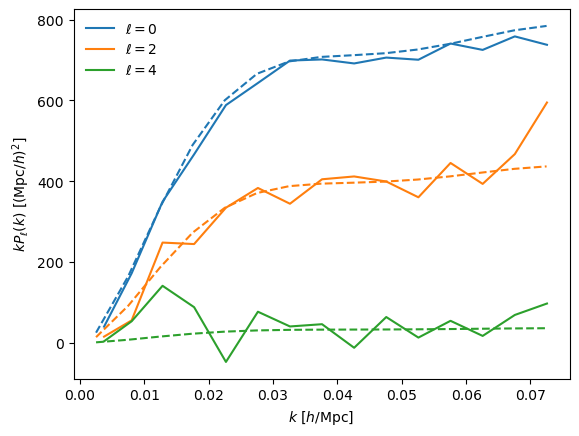

In [8]:
lss.mean(list(map(sum, pks_geo))).plot();
for ell in [0, 2, 4]:
    pole = theory.get(ell)
    plt.plot(k:=pole.coords("k"), k*pole.value(), color=f"C{ell//2}", ls="--")

In [9]:
pks_ric = [
    fw_jit(
        *fkp_fields,
        theory=theory,
        seed=jax.random.key(i * 3 + 87),
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        ric_args=ric_args,
        amr_args=None,
        nam_args=None,
        fkp_norms=fkp_norms,
        binner=binner,
        estimator_weights=None,
        data_regions=tuple(ric_arg.data_regions for ric_arg in ric_args),
        randoms_regions=tuple(ric_arg.randoms_regions for ric_arg in ric_args),
    )
    for i in tqdm(range(nreal_fw), desc="RIC forward modeling")
]

RIC forward modeling: 100%|██████████| 5/5 [00:12<00:00,  2.60s/it]


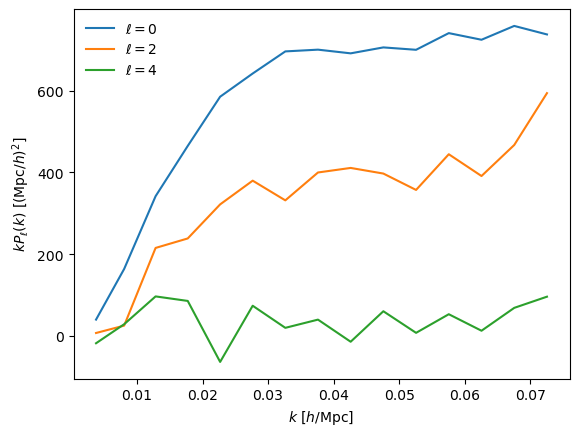

In [10]:
lss.mean(list(map(sum, pks_ric))).plot();

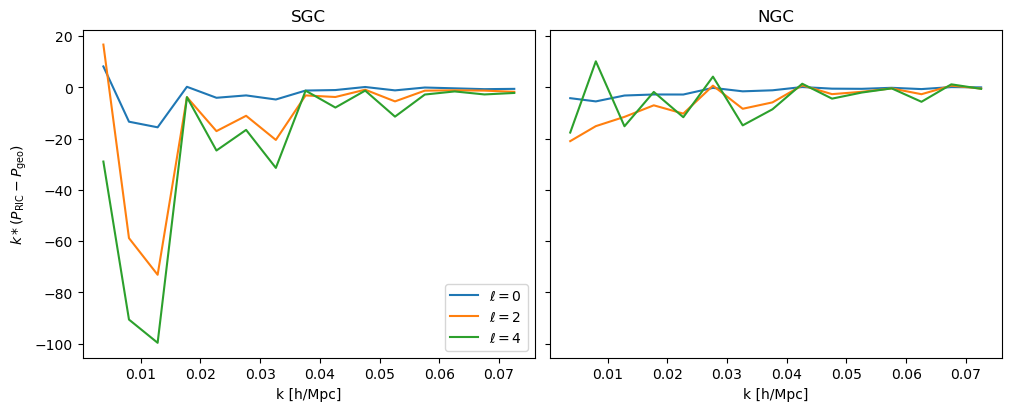

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True, layout="constrained")

for isurvey, (ax, nsurvey) in enumerate(zip(axes, ["SGC", "NGC"])):
    for ell in [0, 2, 4]:
        pole_geo = lss.mean([pk_geo[isurvey] for pk_geo in pks_geo]).get(ell)
        pole_ric = lss.mean([pk_fw[isurvey] for pk_fw in pks_ric]).get(ell)
        k = pole_ric.coords("k")
        ax.plot(k, k * (pole_ric.value() - pole_geo.value()), label=f"$\\ell = ${ell}")
    ax.set_title(nsurvey)
    ax.set_xlabel("k [h/Mpc]")

axes[0].set_ylabel(r"$k * (P_\mathrm{RIC} - P_\mathrm{geo})$")
axes[0].legend()

# Window spikes with RIC

In [12]:
windows_avg, windows = get_window_spikes(
    mock_survey=mock_survey_catalog,
    theory=theory,
    nreal=3,
    seeds=None,
    batch_size=5,
    mock_survey_args=fkp_fields,
    mock_survey_kwargs={
        "los": LOS,
        "unitary_amplitude": UNITARY_AMPLITUDE,
        "ric_args": ric_args,
        "amr_args": None,
        "nam_args": None,
        "fkp_norms": fkp_norms,
        "binner": binner,
        "estimator_weights": None,
        "data_regions": tuple(ric_arg.data_regions for ric_arg in ric_args),
        "randoms_regions": tuple(ric_arg.randoms_regions for ric_arg in ric_args),
    },
    static_argnames=["los", "unitary_amplitude", "estimator_weights"],
)

Realization: 100%|██████████| 3/3 [01:39<00:00, 33.03s/it]


Text(0.5, 0.98, 'Window function LRG x QSO, Geometry + RIC, GCcomb')

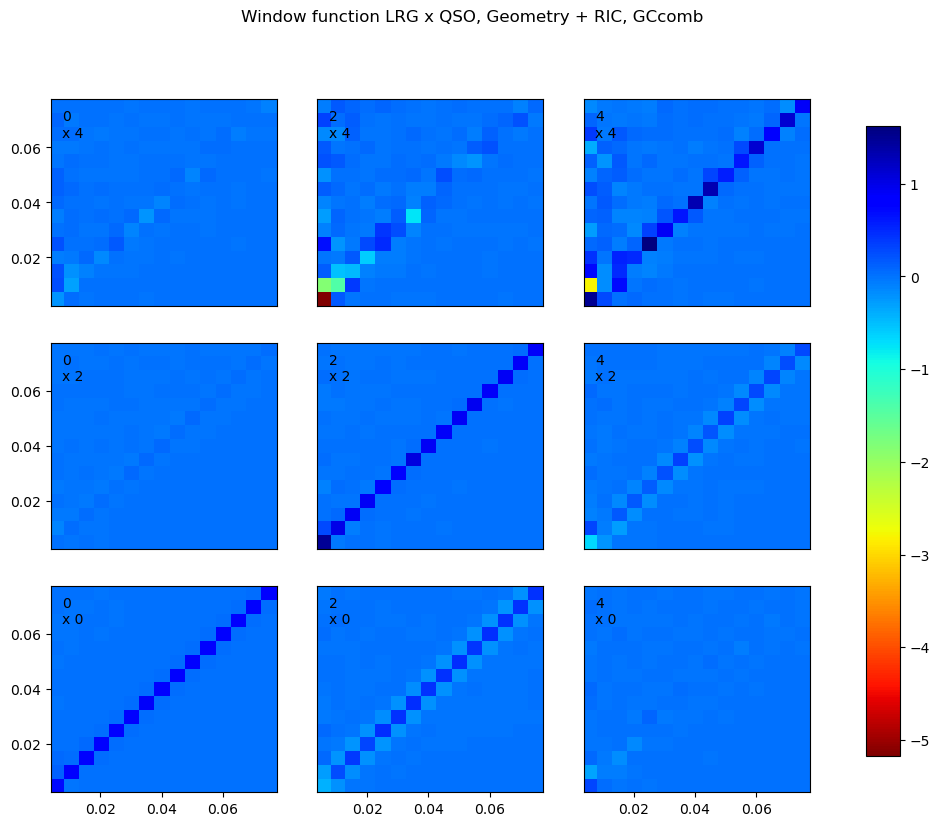

In [13]:
fig = (windows_avg[0] + windows_avg[1]).plot()
fig.suptitle("Window function LRG x QSO, Geometry + RIC, GCcomb")